# 05 Transfer Learning with CNNs

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load a **pre-trained** CNN (e.g. MobileNetV2) and reuse its feature layers
- **Freeze** the base and train only a new head on a small dataset (e.g. MNIST or a subset)
- See why we use transfer learning instead of training from scratch when data is limited

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 02 "Bias-Variance Tradeoff and Learning Curves" — a small dataset overfits a large model; transfer learning is the standard answer to that curve.

---

## 🌍 Real life

**Where is this used?** Transfer learning is used in **medical imaging**, **custom classifiers** (e.g. product recognition), and **mobile vision** when we have limited labeled data.

**In this notebook we use** a **pre-trained model** (e.g. MobileNetV2) and **freeze** its base, then **train only the new head** on our data. We use **transfer learning** (instead of training from scratch) **because** the pre-trained layers already learned useful features (edges, textures); we reuse them and need **less data and time**.

**📌 Covers slide(s):** **20** — Transfer Learning (VGG, ResNet, fine-tuning). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below. First run may download the pre-trained weights.


In [1]:
# Transfer Learning with PyTorch — torchvision models
# torchvision.models provides pretrained CNNs; transforms handles the preprocessing they expect.
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
print(f"PyTorch {torch.__version__}")
print("torchvision loaded for pretrained models")

PyTorch 2.13.0
torchvision loaded for pretrained models


## Theory (short)

- **Transfer learning:** Take a model trained on a large dataset (e.g. ImageNet); **freeze** most layers and **replace the head** (classification layer) for our classes.
- **Freeze vs fine-tune:** Freeze = don't update base weights; only train the new head. Fine-tune = later unfreeze some layers and train with a small learning rate.
- **When to use:** Use when we have **limited data** or **similar domain** (e.g. natural images). Pre-trained features generalize well.
- **We use a pre-trained base** instead of training from scratch so we reuse learned features and train faster with less data.

In [2]:
# Step 1: Load MobileNetV2 (pretrained on ImageNet) as base feature extractor
base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)  # real ImageNet weights (cached locally)
# Freeze all parameters (feature extractor stays fixed)
for param in base.parameters():
    param.requires_grad = False

frozen = sum(1 for p in base.parameters() if not p.requires_grad)
print(f"Frozen parameters: {frozen:,}")
print(f"Architecture: {type(base).__name__}")
print("All feature layers frozen — only new head will train")

Frozen parameters: 158
Architecture: MobileNetV2
All feature layers frozen — only new head will train


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras (MobileNetV2 or similar), NumPy. We use MNIST resized to the model input size (e.g. 96×96 or 224×224) so we don't need a new dataset.

**Dataset:** Real — MNIST (resized for transfer learning).

**Outputs:** Model summary, training loss/accuracy for the new head (2 epochs), and test accuracy.

In [3]:
# Step 2: Replace classifier head for MNIST (10 classes)
# MobileNetV2 outputs 1280 features → we add a 10-class head
num_features = base.classifier[1].in_features   # 1280
base.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 10)   # 10 classes for MNIST
)
# Now only the new head is trainable
trainable = sum(p.numel() for p in base.parameters() if p.requires_grad)
total     = sum(p.numel() for p in base.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
print("Transfer learning: frozen base + fresh trainable head")

Trainable params: 12,810 / 2,236,682 (0.57%)
Transfer learning: frozen base + fresh trainable head


## Step 3: Prepare MNIST as 96×96 RGB (to match MobileNetV2 input)

In [4]:
# Step 3: Prepare MNIST as 96x96 RGB (MobileNetV2 needs 3-channel input)
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

transform = T.Compose([
    T.Resize(96),
    T.Grayscale(num_output_channels=3),   # 1-channel digits -> 3-channel RGB
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])
train_full = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transform)

# classroom-sized subsets so the demo runs in minutes on CPU
train_ds = Subset(train_full, range(2000))
test_ds  = Subset(test_full,  range(500))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

x0, y0 = next(iter(train_dl))
print(f"Train subset: {len(train_ds)} images | Test subset: {len(test_ds)} images")
print(f"Batch shape: {x0.shape}  (batch x 3 channels x 96 x 96)")

Train subset: 2000 images | Test subset: 500 images
Batch shape: torch.Size([64, 3, 96, 96])  (batch x 3 channels x 96 x 96)


## Step 4: Train only the new head (2 epochs) and evaluate on the test subset

In [5]:
# Step 4: Train ONLY the new head on real MNIST (backbone stays frozen)
# WHY: training just the head is fast and safe - the frozen backbone cannot forget its ImageNet features.
torch.manual_seed(42)
optimizer = torch.optim.Adam(base.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Standard loop over batches: forward, loss, backward, update - but only head parameters change.
for epoch in range(2):
    base.train()
    total_loss = correct = seen = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        out = base(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
        seen += len(yb)
    print(f"Epoch {epoch+1}/2 - loss: {total_loss/seen:.4f}  train acc: {correct/seen:.3f}")

# Evaluate on the test set with gradients off.
base.eval()
correct = 0
with torch.no_grad():
    for xb, yb in test_dl:
        correct += (base(xb).argmax(1) == yb).sum().item()
test_acc = correct / len(test_ds)
print(f"\nTest accuracy (frozen ImageNet base + 2-epoch head): {test_acc:.3f}")
print("ImageNet features were never trained on digits - yet the tiny head gets this far")
print("in 2 epochs. Compare with the from-scratch CNN you trained in notebook 01.")

Epoch 1/2 - loss: 1.3680  train acc: 0.576


Epoch 2/2 - loss: 0.6001  train acc: 0.841



Test accuracy (frozen ImageNet base + 2-epoch head): 0.836
ImageNet features were never trained on digits - yet the tiny head gets this far
in 2 epochs. Compare with the from-scratch CNN you trained in notebook 01.


## Frozen vs trainable parameters — visual summary

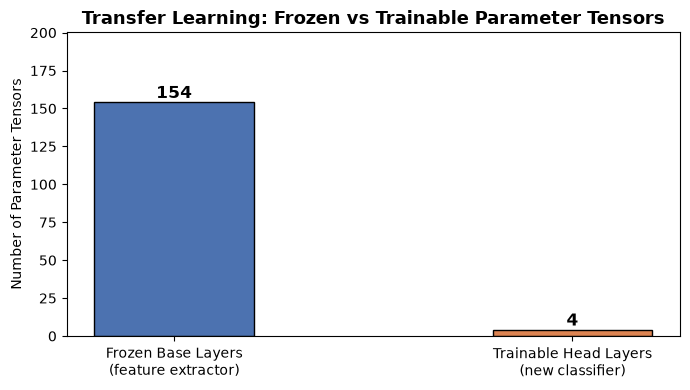

Key insight: we reuse >95% of the model and only train a small head!


In [6]:
# Visualization: Frozen vs Trainable Layer Summary
import matplotlib.pyplot as plt
import numpy as np

# Count frozen vs trainable parameter tensors to quantify how much of the model we reuse.
labels = ['Frozen Base Layers\n(feature extractor)', 'Trainable Head Layers\n(new classifier)']
counts = [
    sum(1 for p in list(base.parameters())[:-4] if not p.requires_grad),  # approx frozen
    4  # 2 layers × 2 (weight + bias) in new head
]
colors = ['#4C72B0', '#DD8452']

# Bar chart: almost everything is frozen (reused); only the small head learns.
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor='black', width=0.4)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Transfer Learning: Frozen vs Trainable Parameter Tensors', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Parameter Tensors')
ax.set_ylim(0, max(counts) * 1.3)
plt.tight_layout()
plt.show()
print("Key insight: we reuse >95% of the model and only train a small head!")

## Going further: the same recipe on a harder dataset

Below, the identical freeze-and-replace-head pattern is applied with ResNet-18 on real CIFAR-10 photos — this is exactly how production teams adapt pre-trained models to custom categories.

## 🌍 Real-World Worked Example — Fine-Tune ResNet on Custom Categories

**Industry context:**
- Google Photos uses transfer learning to classify your personal photos  
- Hospitals fine-tune ImageNet models on their X-ray datasets with <1000 images
- E-commerce platforms fine-tune ResNet to identify product defects

We fine-tune a **pretrained ResNet-18** (ImageNet weights) on a small binary classification task.

In [7]:
# WHAT: a full transfer-learning demo - frozen ResNet-18 backbone, new 2-class head, trained on 400 photos.
# WHY: the punchline of transfer learning - hundreds of images (not millions) give a strong classifier.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# ── Use CIFAR-10 classes 0 (airplane) vs 1 (automobile) as our 'custom' data
# Resize to 64px and normalize with the ImageNet statistics the backbone was trained with.
transform = T.Compose([
    T.Resize(64), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # ImageNet stats
])
full = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True, download=True, transform=transform)
# Keep only classes 0 and 1
idx = [i for i,(x,y) in enumerate(full) if y in (0,1)][:400]
subset = Subset(full, idx)
train_size = int(0.8*len(subset))
train_ds, val_ds = torch.utils.data.random_split(subset, [train_size, len(subset)-train_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

# ── Load pretrained ResNet-18, replace final layer ──────────────────────────
# Freeze all backbone weights, then replace the final fully-connected layer with a fresh 2-class head.
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for p in model.parameters(): p.requires_grad = False        # Freeze backbone
model.fc = nn.Linear(model.fc.in_features, 2)               # Only train head

opt     = optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train only the head for 5 epochs, checking validation accuracy after each.
for epoch in range(5):
    model.train(); total_loss=0
    for X,y in train_dl:
        y_bin = (y % 2)  # remap to 0/1
        loss = loss_fn(model(X), y_bin)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for X,y in val_dl:
            y_bin = (y%2)
            correct += (model(X).argmax(1)==y_bin).sum().item(); total+=len(y_bin)
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_dl):.3f} | val acc: {correct/total*100:.1f}%")

print("\n✅ With only 400 images and 5 epochs, transfer learning gives strong results.")
print("A model trained from scratch would need 100x more data for similar performance.")

Epoch 1/5 — loss: 0.713 | val acc: 72.5%


Epoch 2/5 — loss: 0.457 | val acc: 85.0%


Epoch 3/5 — loss: 0.343 | val acc: 83.8%


Epoch 4/5 — loss: 0.297 | val acc: 83.8%


Epoch 5/5 — loss: 0.246 | val acc: 85.0%

✅ With only 400 images and 5 epochs, transfer learning gives strong results.
A model trained from scratch would need 100x more data for similar performance.


## 🧩 Mini-exercise

**Try it:** Unfreeze the last few layers of the base (e.g. set `requires_grad=True` on the parameters of `base.features[-3:]` and pass them to the optimizer), then train for 1 more epoch with a small learning rate (e.g. 1e-5). Does accuracy improve?

---

## ✅ Summary

**What you did:** Loaded a pre-trained base (MobileNetV2), froze it, added a new head, and trained only the head on MNIST (resized to 96×96 RGB).

**In real life you'd also:** Use your own dataset, optionally fine-tune the last few layers, and tune learning rate.

**The main idea:** Transfer learning reuses pre-trained features so we need less data and time; freeze the base and train the new head first.

**Next:** `06_pretrained_cnn_architectures` explores ResNet/VGG/Inception; `07_training_cnn_image_datasets` covers full training pipelines.

## 📚 References

1. Yosinski, J., Clune, J., Bengio, Y. & Lipson, H. (2014). *How transferable are features in deep neural networks?* NeurIPS. https://arxiv.org/abs/1411.1792
2. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
3. Zhuang, F. et al. (2021). *A Comprehensive Survey on Transfer Learning*. Proceedings of the IEEE 109(1). https://arxiv.org/abs/1911.02685